<div style="text-align: right;">
<img src="TSs_Logo_UTN.svg" width="150" />
</div>

---

<h2 style="text-align: center;">Departamento de Electrónica</h2>

<h3 style="text-align: center;">(950416) Procesamiento Digital de Señales - R6051</h3>

<p style="text-align: center;">
<strong>Docente</strong><br>
Dr. Ing. Mariano Llamedo Soria
</p>

---

<h1 style="text-align: center;"> 1° Tarea semanal: Primeros pasos en la simulación</h1>

---

Por *David Moharos*

---

## Consigna

En este primer trabajo comenzaremos por diseñar un generador de señales que utilizaremos en las primeras simulaciones que hagamos. La primera tarea consistirá en programar una función que genere señales senoidales y que permita parametrizar:

la amplitud máxima de la senoidal [V],  
su valor medio [V],  
la frecuencia [Hz],  
la fase [rad],  
la cantidad de muestras digitalizada por el ADC [# muestras],  
la frecuencia de muestreo del ADC.

Es decir que la función debería admitir ser llamada de la siguiente manera:

> tt, xx = mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs)

Tanto xx como tt deben ser vectores de Nx1. Puede resultar útil el módulo de visualización **matplotlib.pyplot** donde se encontrarán todas las funciones de visualización estilo *MATLAB*. Para usarlo:

> import matplotlib.pyplot as plt  
> plt.plot(tt, xx)

## Introducción y configuración
En esta sección se importan las librerías necesarias (`numpy`, `matplotlib.pyplot` y `scipy.signal`) y se definen los parámetros globales de la simulación, como la frecuencia de muestreo y las frecuencias de las señales a generar.

In [125]:
# Importación de módulos que utilizaremos:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig

#%% Parámetros de ejemplo
N  = 1000    # cantidad de muestras
fs = 1000    # frecuencia de muestreo
ff_sen = 20  # frecuencia de señal senoidal

## Definición de funciones
A continuación, se define una función para generar una señal **senoidal**. Dicha función devuelve un vector de tiempo `tt` y un vector de amplitud `xx` de dimensiones $N \times 1$.

In [126]:
#%%  Señal senoidal
def funcion_senal_senoidal(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    
    """
    Genera una señal senoidal con los siguientes argumentos:
        
    vmax -- Amplitud máxima [V]
    dc   -- Valor medio [V]
    ff   -- Frecuencia de la senoidal [Hz]
    ph   -- Fase [rad]
    nn   -- Cantidad de muestras (#)
    fs   -- Frecuencia de muestreo [Hz]
    
    Retorna:
    tt   -- Vector de tiempo (Nx1)
    xx   -- Vector de amplitud (Nx1)
    
    """
    
    # Vector de tiempo tt
    tt = np.arange(nn * 1/fs, step = 1/fs)
    
    # Vector de señal senoidal
    xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc
    
    return tt, xx
    

## Generación y visualización de señales
Se procede a instanciar las señales utilizando las funciones definidas anteriormente y se grafican para verificar su correcto funcionamiento en el dominio del tiempo.

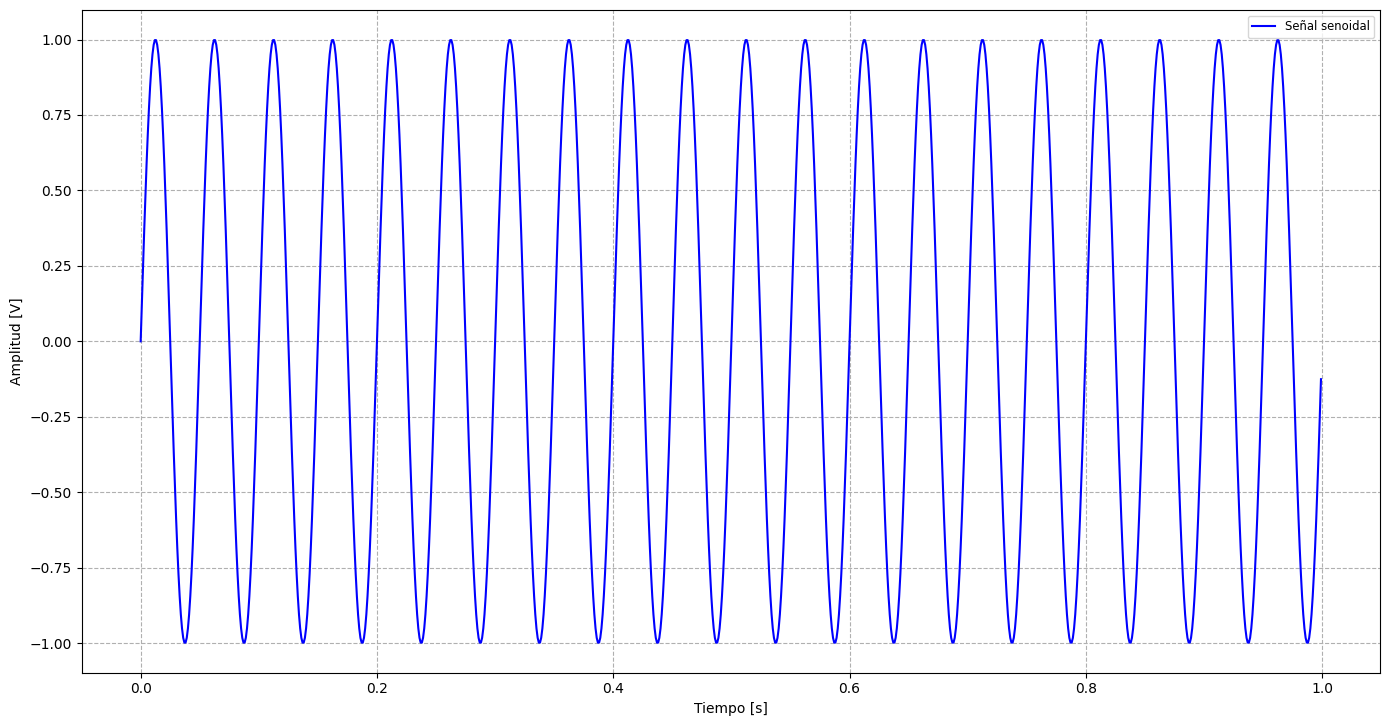

In [127]:
#%%  Ejemplos de uso

tt, x_sen = funcion_senal_senoidal(vmax=1, dc=0, ff=ff_sen, ph=0, nn=N, fs=fs)

#%%  Gráficas por caso:
fig, axs = plt.subplots(1, 1, figsize=(14, 8), sharex=True)

param_senal_sen = {'color': 'blue', 'lw': 1.5, 'label': 'Señal senoidal'}

# Gráfico 1: Señal senoidal
axs.plot(tt, x_sen, **param_senal_sen)
axs.set_ylabel('Amplitud [V]')
axs.set_xlabel('Tiempo [s]')
axs.grid(True, linestyle='--')
axs.legend(loc='upper right', fontsize='small')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Implementación de ruido y SNR
Se implementa una función que añade ruido blanco gaussiano a una señal dada, permitiendo controlar la relación señal a ruido (**SNR**) en decibeles. Se utiliza la varianza muestral (`np.var`) para estimar la potencia.

In [128]:
#%%  Implementación de función para añadir ruido

def funcion_agregar_ruido_snr(sig, snr_db):
    """
    Suma ruido gaussiano a una señal para obtener un SNR específico.
    
    Argumentos:
    sig    -- Vector de la señal original (Nx1)
    snr_db -- Relación Señal-Ruido deseada en decibeles [dB]
    
    """
    # Potencia de la señal original - varianza
    p_sig = np.var(sig)
    
    # Potencia de ruido necesaria
    p_ruido = p_sig / (10**(snr_db / 10))
    
    # Desviación estándar del ruido
    sigma_ruido = np.sqrt(p_ruido)
    
    # Ruido normal (media 0, sigma calculado)
    media = 0.0
    ruido = np.random.normal(media, sigma_ruido, sig.shape)
    
    # Señal ruidosa
    return sig + ruido


## Validación y análisis de señales ruidosas
Finalmente, se aplica un ruido con un **SNR de 10 dB** a las señales generadas y se comparan las potencias calculadas para validar la precisión del generador de ruido.

Potencia señal: 0.5000 W
Potencia ruido: 0.0492 W


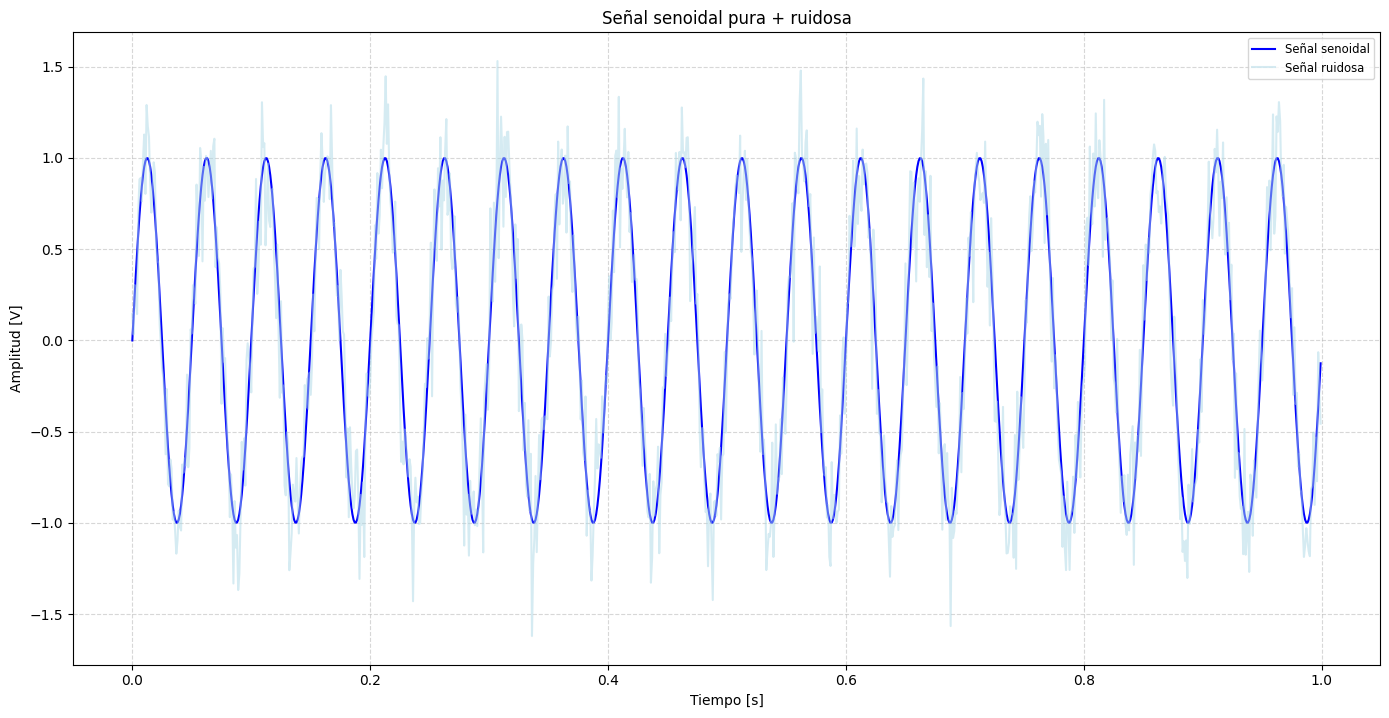

In [129]:
#%%  Ejemplo de uso 

# Se añade ruido para un SNR de 10 dB (el ruido tendrá 1/10 de la potencia)
SNR_deseado = 10
x_sen_n = funcion_agregar_ruido_snr(x_sen, SNR_deseado)

# Verificación
print(f"Potencia señal: {np.var(x_sen):.4f} W")
print(f"Potencia ruido: {np.var(x_sen_n - x_sen):.4f} W")

# Generación de señales ruidosas
x_sen_n = funcion_agregar_ruido_snr(x_sen, SNR_deseado)

#%%  Gráfica señal senoidal + ruido
fig, axs = plt.subplots(1, 1, figsize=(14, 8), sharex=True)

param_ruido_sen = {'color': 'lightblue', 'alpha': 0.5, 'lw': 1.5, 'label': 'Señal ruidosa'}

# Subplot Senoidal
axs.plot(tt, x_sen, **param_senal_sen)
axs.plot(tt, x_sen_n, **param_ruido_sen)
axs.set_ylabel('Amplitud [V]')
axs.set_xlabel('Tiempo [s]')
axs.set_title('Señal senoidal pura + ruidosa')
axs.grid(True, linestyle='--', alpha=0.5)
axs.legend(loc='upper right', fontsize='small')

plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()

## Bonus:

💎 Realizar los experimentos que se comentaron en clase (fs = 1000 Hz, N = 1000 muestras) siguiendo la notación de la función definida más arriba con ff = (500, 999, 1001, 2001) [Hz]  

🤯 Implementar alguna otra señal propia de un generador de señales.

### Análisis de la señal senoidal a distintas frecuencias

Se realiza el análisis de la señal senoidal de distintas frecuencias a la misma frecuencia de muestreo y se estudia qué ocurre con su representación gráfica por caso:

In [130]:
tt, x_sen_500 = funcion_senal_senoidal(vmax=1, dc=0, ff=500, ph=0, nn=N, fs=fs)
tt, x_sen_999 = funcion_senal_senoidal(vmax=1, dc=0, ff=999, ph=0, nn=N, fs=fs)
tt, x_sen_1001 = funcion_senal_senoidal(vmax=1, dc=0, ff=1001, ph=0, nn=N, fs=fs)
tt, x_sen_2001 = funcion_senal_senoidal(vmax=1, dc=0, ff=2001, ph=0, nn=N, fs=fs)

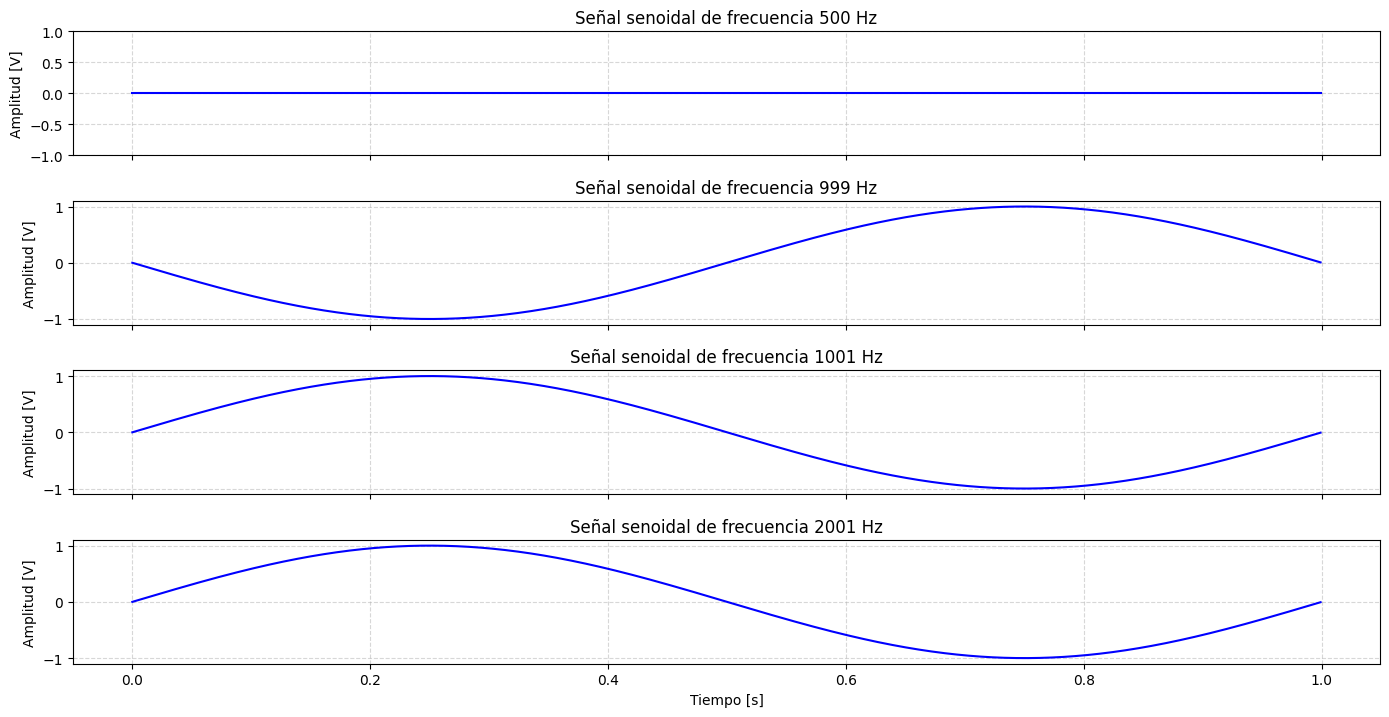

In [131]:
fig, axs = plt.subplots(4, 1, figsize=(14, 8), sharex=True)

axs[0].plot(tt, x_sen_500, **param_senal_sen)
axs[0].set_ylim(-1.0, 1.0)
axs[0].set_ylabel('Amplitud [V]')
axs[0].set_title('Señal senoidal de frecuencia 500 Hz')
axs[0].grid(True, linestyle='--', alpha=0.5)
#axs[0].legend(loc='upper right', fontsize='small')

axs[1].plot(tt, x_sen_999, **param_senal_sen)
axs[1].set_ylabel('Amplitud [V]')
axs[1].set_title('Señal senoidal de frecuencia 999 Hz')
axs[1].grid(True, linestyle='--', alpha=0.5)
#axs[1].legend(loc='upper right', fontsize='small')

axs[2].plot(tt, x_sen_1001, **param_senal_sen)
axs[2].set_ylabel('Amplitud [V]')
axs[2].set_title('Señal senoidal de frecuencia 1001 Hz')
axs[2].grid(True, linestyle='--', alpha=0.5)
#axs[2].legend(loc='upper right', fontsize='small')

axs[3].plot(tt, x_sen_2001, **param_senal_sen)
axs[3].set_xlabel('Tiempo [s]')
axs[3].set_ylabel('Amplitud [V]')
axs[3].set_title('Señal senoidal de frecuencia 2001 Hz')
axs[3].grid(True, linestyle='--', alpha=0.5)
#axs[3].legend(loc='upper right', fontsize='small')

plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()

Observamos lo siguiente:

Una señal senoidal de frecuencia 500 Hz, muestreada a una frecuencia de 1000 Hz, está siendo muestreada en el límite de Nyquist, a razón de dos muestras por ciclo, y su representación se verá afectada por la fase de señal.

En la primera imagen, cuya fase es de 0 rad, la señal se representa como una señal de amplitud 0 V (aunque se trate de una señal senoidal de 1 V de amplitud) porque las muestras caen en los cruces por cero.

Ajustando la fase apropiadamente, por caso, $\frac{\pi}{2}$ rad, o cualquier múltiplo por caso, $\frac{\pi}{2} + k\pi$ rad, de manera tal que las muestras caigan en los picos de la señal, podríamos representar correctamente la señal de 1 V de amplitud.

Si la frecuencia de la señal es ahora de 999 Hz y es muestreada a la misma frecuencia de 1000 Hz, está siendo muestreada por encima de la frecuencia de Nyquist y por lo tanto sufre aliasing.

En la segunda imagen, se observa que esto provoca que su representación corresponda a la de una señal senoidal de 1 Hz, en lugar de 999 Hz. Esto sucede porque, al muestrear cada 1 ms, cada muestra cae apenas *atrasada* respecto al ciclo anterior.

Para el caso de la señal senoidal de 1001 Hz, muestreada a la misma frecuencia de 1000 Hz, sucede algo similar al caso anterior: su representación corresponde una señal senoidal de 1 Hz pero ahora cada muestra queda apenas *adelantada* respecto al ciclo anterior.

Es por eso que, en la tercera imagen, se ve en amplitud, la misma representación que para el caso de 999 Hz, pero con un rotación de fase de $\pi$ rad.

Finalmente, en la cuarta imagen, se observa que para la señal de frecuencia 2001 Hz, sucede lo mismo que para el caso de la señal senoidal de 1001 Hz debido a que el efecto ocurre a un múltiplo de la frecuencia de muestreo, $n \cdot fs$, con $n = 1, 2, 3 ...$

Con lo cual, de forma análoga, podríamos observar este mismo efecto para una señal senoidal de 1999 Hz respecto a la de 999 Hz.

### Generador de señales

A partir de la implementación de la función para señales senoidales, se realiza una generalización de manera tal de implementar también señales rectangulares, triangulares y diente de sierra.

A través del parámetro `senal`, se indica mediante un `string` la señal deseada a implementar:

In [134]:
#%%  Generador de señales
def funcion_generador_de_senales(vmax=1, dc=0, ff=1, ph=0, nn=100, fs=100, senal="senoidal"):
    
    """
    Genera una señal con los siguientes argumentos:
        
    vmax  -- Amplitud máxima [V]
    dc    -- Valor medio [V]
    ff    -- Frecuencia de la senoidal [Hz]
    ph    -- Fase [rad]
    nn    -- Cantidad de muestras (#)
    fs    -- Frecuencia de muestreo [Hz]
    senal -- "senoidal", "cuadrada", "triangular", "diente de sierra"
    
    Retorna:
    tt   -- Vector de tiempo (Nx1)
    xx   -- Vector de amplitud (Nx1)
    
    """
    
    # Intervalo entre muestras (periodo de muestreo)
    ts = 1/fs
    
    # Vector de tiempo tt
    tt = np.arange(0.0, N*ts, ts)

    if senal == "senoidal":
        xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc
        
    elif senal == "cuadrada":
        xx = vmax * signal.square(2 * np.pi * ff * tt + ph) + dc
        
    elif senal == "triangular":
        # width=0.5, triangular
        xx = vmax * signal.sawtooth(2 * np.pi * ff * tt + ph, width=0.5) + dc
    
    elif senal == "diente de sierra":
        # width=0, diente de sierra
        xx = vmax * signal.sawtooth(2 * np.pi * ff * tt + ph, width=0.0) + dc
    
    return tt, xx

Se grafican las señales implementadas para verificar el correcto funcionamiento:

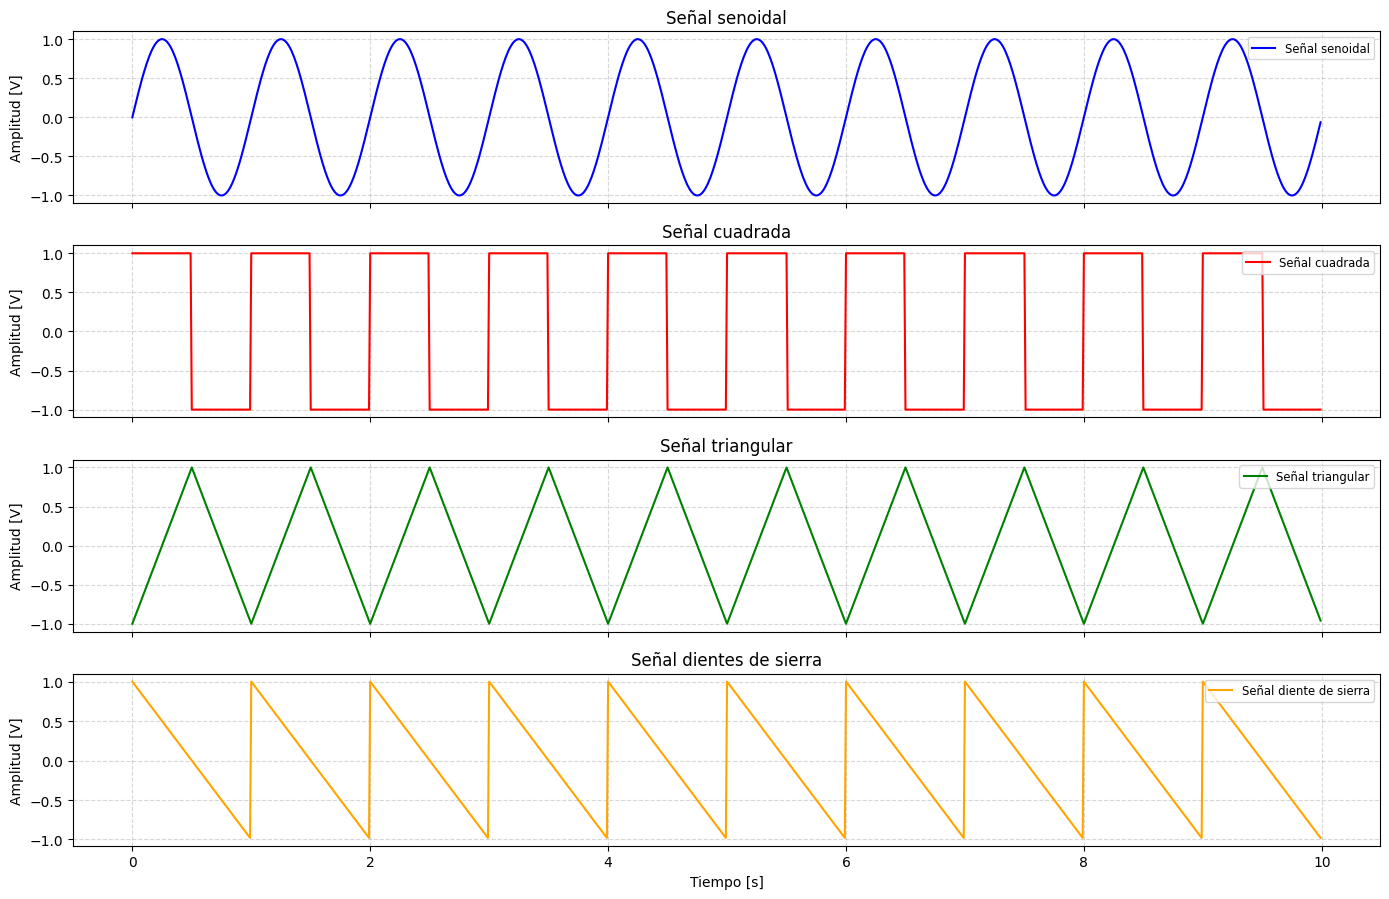

In [133]:
tt, xx_sen = funcion_generador_de_senales()
tt, xx_cua = funcion_generador_de_senales(senal="cuadrada")
tt, xx_tri = funcion_generador_de_senales(senal="triangular")
tt, xx_die = funcion_generador_de_senales(senal="diente de sierra")

fig, axs = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

param_senal_cua = {'color': 'red', 'lw': 1.5, 'label': 'Señal cuadrada'}
param_senal_tri = {'color': 'green', 'lw': 1.5, 'label': 'Señal triangular'}
param_senal_die = {'color': 'orange', 'lw': 1.5, 'label': 'Señal diente de sierra'}

# Subplot Senoidal
axs[0].plot(tt, xx_sen, **param_senal_sen)
axs[0].set_ylabel('Amplitud [V]')
axs[0].set_title('Señal senoidal')
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].legend(loc='upper right', fontsize='small')

axs[1].plot(tt, xx_cua, **param_senal_cua)
axs[1].set_ylabel('Amplitud [V]')
axs[1].set_title('Señal cuadrada')
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].legend(loc='upper right', fontsize='small')

axs[2].plot(tt, xx_tri, **param_senal_tri)
axs[2].set_ylabel('Amplitud [V]')
axs[2].set_title('Señal triangular')
axs[2].grid(True, linestyle='--', alpha=0.5)
axs[2].legend(loc='upper right', fontsize='small')

axs[3].plot(tt, xx_die, **param_senal_die)
axs[3].set_xlabel('Tiempo [s]')
axs[3].set_ylabel('Amplitud [V]')
axs[3].set_title('Señal dientes de sierra')
axs[3].grid(True, linestyle='--', alpha=0.5)
axs[3].legend(loc='upper right', fontsize='small')

plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()